# Analyse approfondie — B12 / véhicules de 0 an, R24 et R11

Je pars de l'[analyse globale](analyse_globale.ipynb) et conserve les premiers croisements.
J'approfondis ensuite trois axes : **B12 / véhicules de 0 an**, **R24 pour son volume** et **R11 pour sa fréquence**.
R24 est étudiée même si elle ne passe pas le seuil automatique de fréquence : sa taille justifie ce choix.

Je compare les mêmes tranches de caractéristiques, puis deux caractéristiques ensemble.
Ces groupes ne sont pas des profils identiques sur toutes les variables. Les résultats restent descriptifs.
Les analyses de sensibilité changent temporairement le périmètre, sans supprimer de données de référence.
Ce notebook repart des fichiers bruts et peut être exécuté seul.

## 1. Préparer les données et les repères

Je relis les deux fichiers bruts, je mets les six contrats orphelins de côté et je conserve tous les contrats de `freq`.
Le nombre de sinistres déclaré vient de `ClaimNb`. Les montants non retrouvés restent inconnus.

In [1]:
from pathlib import Path

# Retrouver le dossier du projet depuis la racine ou depuis notebook.
racine = Path.cwd()
if racine.name == 'notebook':
    racine = racine.parent

import pandas as pd
import numpy as np

colonnes_freq = [
    'IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge',
    'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region'
]

# 14 lignes de description dans freq, 4 dans sev.
# quotechar retire les apostrophes autour des catégories.
df_freq = pd.read_csv(
    racine / 'data/raw/freMTPL2freq.arff', skiprows=14, names=colonnes_freq,
    quotechar="'", na_values='?', dtype={'IDpol': 'int64'}
)
df_sev = pd.read_csv(
    racine / 'data/raw/freMTPL2sev.arff', skiprows=4, names=['IDpol', 'ClaimAmount'],
    quotechar="'", na_values='?', dtype={'IDpol': 'int64'}
)

import matplotlib.pyplot as plt

In [2]:
# Mettre de côté les sinistres dont le contrat est absent de freq.
orphelins = ~df_sev['IDpol'].isin(df_freq['IDpol'])
df_sev_orphelins = df_sev.loc[orphelins].copy()
df_sev_rapprochable = df_sev.loc[~orphelins].copy()

# Regrouper les sinistres pour avoir une ligne par contrat.
df_agg_sev = (
    df_sev_rapprochable.groupby('IDpol', as_index=False)
        .agg(
            NbSinister=('IDpol', 'count'),
            TotalAmount=('ClaimAmount', 'sum')
        )
)

# Garder tous les contrats de freq.
# validate vérifie qu'il y a une seule ligne par IDpol de chaque côté.
df_unified = pd.merge(
    df_freq, df_agg_sev, on='IDpol', how='left', validate='one_to_one'
)

# Conditions pour distinguer les situations après la jointure.
is_na = df_unified['NbSinister'].isna()
has_claim = df_unified['ClaimNb'] > 0
same_count = df_unified['ClaimNb'] == df_unified['NbSinister']

df_unified['Status'] = np.select(
    [is_na & has_claim,
     is_na & ~has_claim,
     ~is_na & has_claim & same_count,
     ~is_na & has_claim & ~same_count],
    ['Montant non retrouvé', 'Sans sinistre',
     'Nombre concordant', 'Nombre différent'],
    default='À vérifier'
)

# Contrôles de la table obtenue.
print("Nombre de contrats :", len(df_unified))
print("IDpol répétés :", df_unified['IDpol'].duplicated().sum())
print("Nombre total de sinistres déclaré :", df_unified['ClaimNb'].sum())
print("Exposition conservée :",
      df_unified['Exposure'].sum() == df_freq['Exposure'].sum())
print("Montant rapprochable conservé :",
      round(df_unified['TotalAmount'].sum(), 2)
      == round(df_sev_rapprochable['ClaimAmount'].sum(), 2))
print(df_unified['Status'].value_counts())

print("Contrats avec un nombre de sinistres différent :")
print(df_unified.loc[
    df_unified['Status'] == 'Nombre différent',
    ['IDpol', 'ClaimNb', 'NbSinister']
].to_string(index=False))

print("Contrats orphelins mis de côté :", df_sev_orphelins['IDpol'].nunique())
print("Lignes de sinistres mises de côté :", len(df_sev_orphelins))

Nombre de contrats : 678013
IDpol répétés : 0
Nombre total de sinistres déclaré : 36102
Exposition conservée : True
Montant rapprochable conservé : True
Status
Sans sinistre           643953
Nombre concordant        24943
Montant non retrouvé      9116
Nombre différent             1
Name: count, dtype: int64
Contrats avec un nombre de sinistres différent :
  IDpol  ClaimNb  NbSinister
4158255        2         1.0
Contrats orphelins mis de côté : 6
Lignes de sinistres mises de côté : 195


Je recalcule les KPI pour garder les mêmes repères : **678 013 contrats**, **36 102 sinistres déclarés**
et une fréquence de **10,07 sinistres pour 100 années d'exposition**.
Les montants concernent seulement les sinistres rapprochés.

In [3]:
# Calculer les totaux du portefeuille.
nb_contrats = len(df_unified)
exposition_totale = df_unified['Exposure'].sum()
nb_sinistres_declares = df_unified['ClaimNb'].sum()
nb_sinistres_observes = df_unified['NbSinister'].sum()

# Additionner les montants disponibles, sans remplacer les NaN par zéro.
# min_count=1 garde un résultat NaN si aucun montant n'est disponible.
montant_observe = df_unified['TotalAmount'].sum(min_count=1)

# Calculer les ratios à partir des totaux.
frequence100 = nb_sinistres_declares / exposition_totale * 100
cout_moyen_observe = montant_observe / nb_sinistres_observes
cout_observe_par_annee = montant_observe / exposition_totale

# Mesurer la part des contrats sinistrés sans montant retrouvé.
nb_contrats_sinistres = (df_unified['ClaimNb'] > 0).sum()
nb_contrats_sans_montant = (df_unified['Status'] == 'Montant non retrouvé').sum()
part_sans_montant = nb_contrats_sans_montant / nb_contrats_sinistres * 100

# Une seule ligne pour résumer le portefeuille.
df_kpi = pd.DataFrame({
    'NbContrats': [nb_contrats],
    'ExpositionTotaleAnnees': [exposition_totale],
    'NbSinistresDeclares': [nb_sinistres_declares],
    'NbSinistresObserves': [nb_sinistres_observes],
    'MontantObserveEuros': [montant_observe],
    'FrequencePour100Annees': [frequence100],
    'CoutMoyenObserveEuros': [cout_moyen_observe],
    'CoutObserveParAnneeEuros': [cout_observe_par_annee],
    'PartContratsSinistresSansMontantPct': [part_sans_montant]
})

# .T affiche les KPI verticalement pour faciliter la lecture.
# df_kpi garde une seule ligne et les valeurs non arrondies.
print(df_kpi.round(2).T)

                                               0
NbContrats                             678013.00
ExpositionTotaleAnnees                 358499.45
NbSinistresDeclares                     36102.00
NbSinistresObserves                     26444.00
MontantObserveEuros                  59909216.50
FrequencePour100Annees                     10.07
CoutMoyenObserveEuros                    2265.51
CoutObserveParAnneeEuros                  167.11
PartContratsSinistresSansMontantPct        26.76


Je reprends les tranches de l'analyse globale. Les âges de 100 ans restent identifiés à part.
Les bornes hautes des tranches sont incluses, par exemple 25-34 ans pour les âges entiers supérieurs à 24 et inférieurs ou égaux à 34.

In [4]:
# Garder la table unifiée et créer une copie avec les tranches.
df_segments = df_unified.copy()

df_segments['TrancheAgeConducteur'] = pd.cut(
    df_segments['DrivAge'],
    bins=[17, 24, 34, 44, 54, 64, 74, 99, np.inf],
    labels=['18-24 ans', '25-34 ans', '35-44 ans', '45-54 ans',
            '55-64 ans', '65-74 ans', '75-99 ans', '100 ans et plus (à vérifier)']
)

df_segments['TrancheAgeVehicule'] = pd.cut(
    df_segments['VehAge'],
    bins=[-1, 0, 2, 5, 10, 20, 99, np.inf],
    labels=['0 an', '1-2 ans', '3-5 ans', '6-10 ans', '11-20 ans',
            '21-99 ans', '100 ans et plus (à vérifier)']
)

df_segments['TrancheBonusMalus'] = pd.cut(
    df_segments['BonusMalus'],
    bins=[0, 50, 75, 100, 125, 150, 200, np.inf],
    labels=['50 ou moins', '51-75', '76-100', '101-125',
            '126-150', '151-200', '201 et plus']
)

df_segments['TranchePuissance'] = pd.cut(
    df_segments['VehPower'],
    bins=[0, 5, 7, 9, 11, np.inf],
    labels=['5 ou moins', '6-7', '8-9', '10-11', '12 et plus']
)

df_segments['TrancheDensite'] = pd.cut(
    df_segments['Density'],
    bins=[0, 100, 500, 1000, 5000, 20000, np.inf],
    labels=['1-100', '101-500', '501-1 000', '1 001-5 000',
            '5 001-20 000', '20 001 et plus']
)

segments_tranches = [
    'TrancheAgeConducteur', 'TrancheAgeVehicule', 'TrancheBonusMalus',
    'TranchePuissance', 'TrancheDensite'
]

# Chaque contrat doit appartenir à une tranche pour chaque variable.
print("Contrats sans tranche attribuée :")
print(df_segments[segments_tranches].isna().sum())

Contrats sans tranche attribuée :
TrancheAgeConducteur    0
TrancheAgeVehicule      0
TrancheBonusMalus       0
TranchePuissance        0
TrancheDensite          0
dtype: int64


## 2. Choisir les segments à approfondir

Pour cette exploration, je retiens les groupes qui ont :

- au moins **10 000 contrats** ;
- au moins **1 000 années d'exposition** ;
- une fréquence au moins **20 % supérieure à celle du portefeuille**, soit environ **12,08 sinistres pour 100 années**.

Ce sont des critères de priorité que je peux modifier dans la cellule suivante.
Ils ne constituent pas un test statistique. Je garde les autres groupes dans le tableau complet.

In [5]:
min_contrats = 10000
min_exposition = 1000
marge_frequence = 0.20
seuil_frequence = frequence100 * (1 + marge_frequence)

df_segments['ContratSinistre'] = df_segments['ClaimNb'] > 0
df_segments['SansMontant'] = df_segments['Status'] == 'Montant non retrouvé'

segments_analyse = ['VehGas', 'Area', 'VehBrand', 'Region'] + segments_tranches
tableaux = []

for segment in segments_analyse:
    tableau = df_segments.groupby(segment, as_index=False, observed=True).agg(
        NbContrats=('IDpol', 'count'),
        NbSinistres=('ClaimNb', 'sum'),
        Exposition=('Exposure', 'sum'),
        NbContratsSinistres=('ContratSinistre', 'sum'),
        NbSansMontant=('SansMontant', 'sum')
    )
    tableau['Frequence100'] = tableau['NbSinistres'] / tableau['Exposition'] * 100
    tableau['SansMontantPct'] = (
        tableau['NbSansMontant'] / tableau['NbContratsSinistres'].replace(0, np.nan) * 100
    )

    # Utiliser les mêmes noms de colonnes pour réunir les regroupements.
    tableau = tableau.rename(columns={segment: 'Modalite'})
    tableau['Modalite'] = tableau['Modalite'].astype(str)
    tableau['Variable'] = segment
    tableaux.append(tableau)

df_tous_segments = pd.concat(tableaux, ignore_index=True)

conditions = (
    (df_tous_segments['NbContrats'] >= min_contrats)
    & (df_tous_segments['Exposition'] >= min_exposition)
    & (df_tous_segments['Frequence100'] >= seuil_frequence)
)
df_prioritaires = df_tous_segments.loc[conditions].copy()
df_prioritaires = df_prioritaires.sort_values('NbSinistres', ascending=False)

print(f"Fréquence minimale retenue : {seuil_frequence:.2f} pour 100 années")
print("Nombre de groupes retenus :", len(df_prioritaires))
print(df_prioritaires[[
    'Variable', 'Modalite', 'NbContrats', 'NbSinistres',
    'Exposition', 'Frequence100', 'SansMontantPct'
]].round(2).to_string(index=False))

Fréquence minimale retenue : 12.08 pour 100 années
Nombre de groupes retenus : 9
            Variable       Modalite  NbContrats  NbSinistres  Exposition  Frequence100  SansMontantPct
            VehBrand            B12      166024         8859    64808.61         13.67           53.66
                Area              E      137167         7805    63819.31         12.23           21.92
   TrancheBonusMalus         76-100      111051         7090    44820.34         15.82           18.89
  TrancheAgeVehicule           0 an       57739         5205    16719.03         31.13           77.51
              Region            R11       69791         3978    30208.64         13.17           35.55
TrancheAgeConducteur      18-24 ans       30198         2364    12489.16         18.93           14.75
      TrancheDensite   5 001-20 000       38082         2213    17026.16         13.00           25.33
                Area              F       17954         1131     8129.23         13.91         

**Neuf groupes correspondent aux critères.** Ils concernent B12, les zones E et F, le bonus-malus 76-100,
les véhicules de 0 an, R11, les conducteurs de 18-24 ans et deux tranches de forte densité.

La tranche de bonus-malus 101-125 a une fréquence élevée, mais ses **6 987 contrats** sont sous le seuil de volume choisi ici.
Elle reste visible dans l'analyse globale et pourra servir de comparaison dans les croisements.

Ces neuf groupes se recoupent : un contrat peut être à la fois B12, en R11 et dans une tranche d'âge retenue.
Je compte donc les contrats distincts concernés avant d'aller plus loin.

In [6]:
# Le signe | signifie OU : appartenir à au moins un groupe retenu.
masque_cible = pd.Series(False, index=df_segments.index)

for _, ligne in df_prioritaires.iterrows():
    variable = ligne['Variable']
    modalite = ligne['Modalite']
    masque_cible = masque_cible | (df_segments[variable].astype(str) == modalite)

df_contrats_cibles = df_segments.loc[masque_cible].copy()

print("Somme des tailles des groupes (avec recoupements) :", df_prioritaires['NbContrats'].sum())
print("Contrats distincts dans au moins un groupe :", len(df_contrats_cibles))
print("Sinistres déclarés sur ces contrats :", df_contrats_cibles['ClaimNb'].sum())
print("IDpol répétés dans ce périmètre :", df_contrats_cibles['IDpol'].duplicated().sum())

Somme des tailles des groupes (avec recoupements) : 639308
Contrats distincts dans au moins un groupe : 359446
Sinistres déclarés sur ces contrats : 20164
IDpol répétés dans ce périmètre : 0


Les groupes retenus concernent **359 446 contrats distincts** et **20 164 sinistres déclarés**.
Je ne cumule pas leurs tailles pour mesurer le portefeuille concerné.

Pour comprendre les écarts, je conserve aussi les autres contrats comme groupes de comparaison.
Je regroupe la suite en trois sujets : **B12 et l'âge du véhicule**, **l'âge du conducteur et le bonus-malus**, puis **R11 et la densité**.

In [7]:
# Créer des groupes simples pour comparer les profils.
df_croisements = df_segments.copy()

df_croisements['GroupeMarque'] = np.where(
    df_croisements['VehBrand'] == 'B12', 'B12', 'Autres marques'
)
df_croisements['GroupeVehicule'] = np.where(
    df_croisements['VehAge'] == 0, '0 an', '1-99 ans'
)
df_croisements.loc[df_croisements['VehAge'] >= 100, 'GroupeVehicule'] = '100 ans et plus'

df_croisements['GroupeConducteur'] = np.where(
    df_croisements['DrivAge'] <= 24, '18-24 ans', '25-99 ans'
)
df_croisements.loc[df_croisements['DrivAge'] >= 100, 'GroupeConducteur'] = '100 ans et plus'

df_croisements['GroupeRegion'] = np.where(
    df_croisements['Region'] == 'R11', 'R11', 'Autres régions'
)

# Toutes les durées sont couvertes, y compris celles supérieures à un an.
df_croisements['TrancheExposition'] = pd.cut(
    df_croisements['Exposure'],
    bins=[0, 0.10, 0.50, 1, np.inf],
    labels=['Jusqu’à 0,10 an', '0,10-0,50 an', '0,50-1 an', 'Plus de 1 an']
)
print("Contrats sans tranche d'exposition :", df_croisements['TrancheExposition'].isna().sum())

Contrats sans tranche d'exposition : 0


## 3. B12 : l'écart est-il présent pour tous les âges de véhicule ?

B12 regroupe **166 024 contrats**, avec une fréquence de **13,67** et **53,66 %** de contrats sinistrés sans montant retrouvé.
Je compare B12 aux autres marques, en séparant les véhicules de 0 an de ceux de 1 à 99 ans.
Les âges de 100 ans restent à part.

  GroupeMarque  GroupeVehicule  NbContrats  NbSinistres  Exposition  NbContratsSinistres  NbSansMontant  Frequence100  SansMontantPct
Autres marques            0 an       20670          887     7158.39                  843            262         12.39           31.08
Autres marques        1-99 ans      491294        26356   286517.30                24961           4424          9.20           17.72
Autres marques 100 ans et plus          25            0       15.15                    0              0          0.00             NaN
           B12            0 an       37069         4318     9560.64                 4079           3553         45.16           87.10
           B12        1-99 ans      128955         4541    55247.97                 4177            877          8.22           21.00


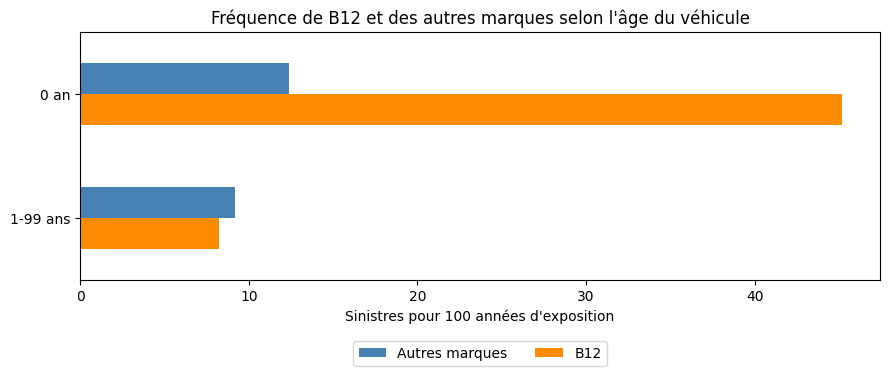

In [8]:
df_marque_vehicule = df_croisements.groupby(
    ['GroupeMarque', 'GroupeVehicule'], as_index=False, observed=True
).agg(
    NbContrats=('IDpol', 'count'),
    NbSinistres=('ClaimNb', 'sum'),
    Exposition=('Exposure', 'sum'),
    NbContratsSinistres=('ContratSinistre', 'sum'),
    NbSansMontant=('SansMontant', 'sum')
)
df_marque_vehicule['Frequence100'] = (
    df_marque_vehicule['NbSinistres'] / df_marque_vehicule['Exposition'] * 100
)
df_marque_vehicule['SansMontantPct'] = (
    df_marque_vehicule['NbSansMontant']
    / df_marque_vehicule['NbContratsSinistres'].replace(0, np.nan) * 100
)
print(df_marque_vehicule.round(2).to_string(index=False))

# Afficher les deux groupes d'âge dont la signification est connue.
graphique = df_marque_vehicule.loc[
    df_marque_vehicule['GroupeVehicule'] != '100 ans et plus'
]
graphique = graphique.pivot(
    index='GroupeVehicule', columns='GroupeMarque', values='Frequence100'
)
graphique.plot.barh(figsize=(9, 4), color=['steelblue', 'darkorange'])
plt.title("Fréquence de B12 et des autres marques selon l'âge du véhicule")
plt.xlabel("Sinistres pour 100 années d'exposition")
plt.ylabel("")
plt.gca().invert_yaxis()
plt.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)
plt.tight_layout()
plt.show()

**Constat :** pour les véhicules de **0 an**, B12 atteint **45,16** sinistres pour 100 années, contre **12,39** pour les autres marques.
Le groupe **B12 / 0 an** contient **37 069 contrats** et **4 318 sinistres**.
Pour les véhicules de **1 à 99 ans**, B12 est à **8,22**, contre **9,20** pour les autres marques.

L'écart observé sur B12 n'est donc pas uniforme : il se concentre sur les véhicules de 0 an.
De plus, **87,10 %** des contrats sinistrés du groupe B12 / 0 an n'ont aucun montant retrouvé.
Je dois faire vérifier ce périmètre avant de conclure sur ses coûts ou sur un effet propre à la marque.

### 3.1. Quel rôle jouent les durées d'exposition ?

Je regarde ensuite la fréquence des véhicules de 0 an selon leur durée d'exposition, avec les véhicules de 1 à 99 ans comme comparaison.
Les tranches sont en années : « jusqu'à 0,10 an » ne signifie pas une période calendaire observée.

 GroupeVehicule TrancheExposition  NbContrats  NbSinistres  Exposition  NbContratsSinistres  NbSansMontant  Frequence100  SansMontantPct
           0 an   Jusqu’à 0,10 an       22545         1631     1217.77                 1557           1464        133.93           94.03
           0 an      0,10-0,50 an       22396         2116     6343.23                 1993           1518         33.36           76.17
           0 an         0,50-1 an       12614         1451     8951.33                 1365            833         16.21           61.03
           0 an      Plus de 1 an         184            7      206.70                    7              0          3.39            0.00
       1-99 ans   Jusqu’à 0,10 an      105048         1829     6312.28                 1715            589         28.98           34.34
       1-99 ans      0,10-0,50 an      204117         8036    62478.83                 7563           1326         12.86           17.53
       1-99 ans         0,50-1 an      31

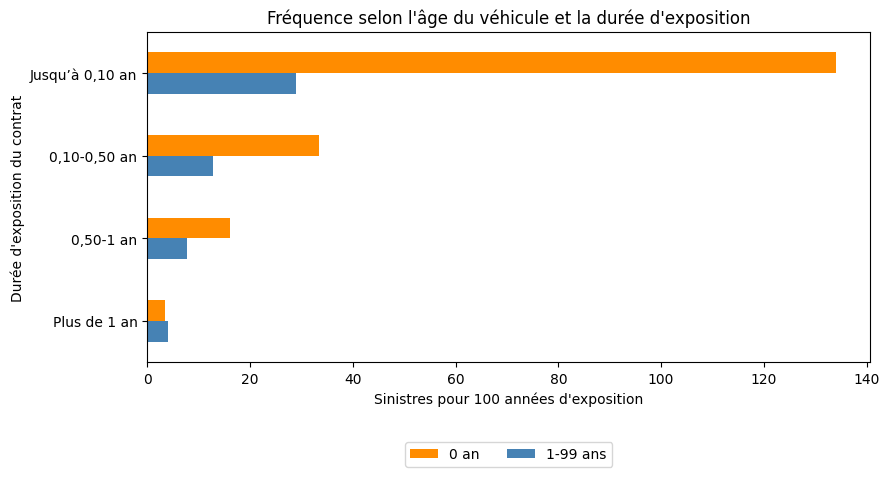

In [9]:
df_vehicule_exposition = df_croisements.groupby(
    ['GroupeVehicule', 'TrancheExposition'], as_index=False, observed=True
).agg(
    NbContrats=('IDpol', 'count'),
    NbSinistres=('ClaimNb', 'sum'),
    Exposition=('Exposure', 'sum'),
    NbContratsSinistres=('ContratSinistre', 'sum'),
    NbSansMontant=('SansMontant', 'sum')
)
df_vehicule_exposition['Frequence100'] = (
    df_vehicule_exposition['NbSinistres'] / df_vehicule_exposition['Exposition'] * 100
)
df_vehicule_exposition['SansMontantPct'] = (
    df_vehicule_exposition['NbSansMontant']
    / df_vehicule_exposition['NbContratsSinistres'].replace(0, np.nan) * 100
)
print(df_vehicule_exposition.round(2).to_string(index=False))

graphique = df_vehicule_exposition.loc[
    df_vehicule_exposition['GroupeVehicule'] != '100 ans et plus'
]
graphique = graphique.pivot(
    index='TrancheExposition', columns='GroupeVehicule', values='Frequence100'
)
graphique.plot.barh(figsize=(9, 5), color=['darkorange', 'steelblue'])
plt.title("Fréquence selon l'âge du véhicule et la durée d'exposition")
plt.xlabel("Sinistres pour 100 années d'exposition")
plt.ylabel("Durée d'exposition du contrat")
plt.gca().invert_yaxis()
plt.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)
plt.tight_layout()
plt.show()

Pour les véhicules de **0 an exposés au plus 0,10 année**, la fréquence atteint **133,93**,
avec **22 545 contrats**, **1 631 sinistres** et **1 217,77 années d'exposition cumulées**.
**94,03 %** de leurs contrats sinistrés sont sans montant retrouvé.
Pour les véhicules de 0 an exposés entre **0,50 et 1 an**, la fréquence est de **16,21**.

Une fréquence supérieure à 100 est possible : il s'agit de sinistres rapportés à une durée, pas d'un pourcentage de contrats.
Ce croisement ne prouve pas que la durée cause les sinistres. Il justifie de vérifier que `ClaimNb` et `Exposure`
couvrent bien le même périmètre et la même durée. Je conserve les valeurs d'origine.

## 4. Les 18-24 ans ont-ils une fréquence plus élevée dans chaque tranche de bonus-malus ?

Je compare les 18-24 ans aux 25-99 ans, à tranche de bonus-malus identique.
Cela permet de voir si l'écart global reste le même dans les sous-groupes, sans isoler un effet causal de l'âge.

GroupeConducteur TrancheBonusMalus  NbContrats  NbSinistres  Exposition  NbContratsSinistres  NbSansMontant  Frequence100  SansMontantPct
 100 ans et plus       50 ou moins           3            0        1.73                    0              0          0.00             NaN
       18-24 ans       50 ou moins         972           63      520.94                   61             11         12.09           18.03
       18-24 ans             51-75        1831           74     1035.22                   70              6          7.15            8.57
       18-24 ans            76-100       25006         1760     9861.30                 1620            277         17.85           17.10
       18-24 ans           101-125        2179          416      973.72                  386             27         42.72            6.99
       18-24 ans           126-150         142           32       67.74                   27              0         47.24            0.00
       18-24 ans           151-200

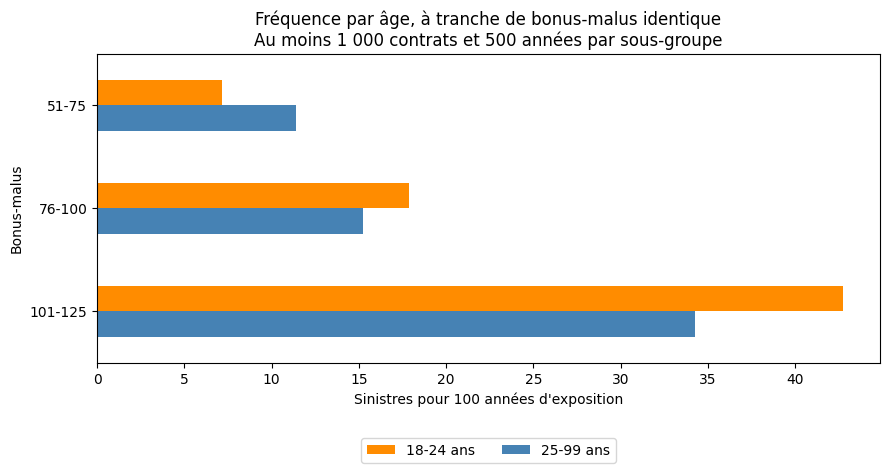

In [10]:
df_age_bonus = df_croisements.groupby(
    ['GroupeConducteur', 'TrancheBonusMalus'], as_index=False, observed=True
).agg(
    NbContrats=('IDpol', 'count'),
    NbSinistres=('ClaimNb', 'sum'),
    Exposition=('Exposure', 'sum'),
    NbContratsSinistres=('ContratSinistre', 'sum'),
    NbSansMontant=('SansMontant', 'sum')
)
df_age_bonus['Frequence100'] = df_age_bonus['NbSinistres'] / df_age_bonus['Exposition'] * 100
df_age_bonus['SansMontantPct'] = (
    df_age_bonus['NbSansMontant'] / df_age_bonus['NbContratsSinistres'].replace(0, np.nan) * 100
)
print(df_age_bonus.round(2).to_string(index=False))

# Pour le graphique, garder les sous-groupes avec assez de volume pour être lisibles.
# Ces seuils d'affichage ne constituent pas un test statistique.
graphique = df_age_bonus.loc[
    (df_age_bonus['NbContrats'] >= 1000)
    & (df_age_bonus['Exposition'] >= 500)
].copy()
graphique = graphique.pivot(
    index='TrancheBonusMalus', columns='GroupeConducteur', values='Frequence100'
)

# Garder les tranches où les deux groupes d'âge passent les seuils.
graphique = graphique.dropna()
graphique.plot.barh(figsize=(9, 5), color=['darkorange', 'steelblue'])
plt.title("Fréquence par âge, à tranche de bonus-malus identique\nAu moins 1 000 contrats et 500 années par sous-groupe")
plt.xlabel("Sinistres pour 100 années d'exposition")
plt.ylabel("Bonus-malus")
plt.gca().invert_yaxis()
plt.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)
plt.tight_layout()
plt.show()

Dans la tranche **76-100**, les 18-24 ans sont à **17,85**, contre **15,25** pour les 25-99 ans.
Les effectifs sont respectivement de **25 006** et **86 045 contrats**.
Dans la tranche **101-125**, les fréquences sont de **42,72** et **34,25**, sur des volumes plus faibles.

En revanche, dans la tranche **51-75**, les 18-24 ans sont à **7,15**, contre **11,38** pour les 25-99 ans.
Le premier chiffre repose sur **74 sinistres** : je garde cet effectif visible et je reste prudent sur sa stabilité.

L'écart selon l'âge n'est donc pas identique dans toutes les tranches de bonus-malus.
Les autres caractéristiques, comme le véhicule et la zone, peuvent encore différer entre les groupes.

## 5. R11, zones E/F et forte densité : plusieurs lectures du même contexte ?

Je commence par regarder les densités observées dans chaque zone.
Cela évite de considérer automatiquement la zone et la densité comme deux signaux indépendants.

In [11]:
df_zones = df_croisements.groupby('Area', as_index=False).agg(
    NbContrats=('IDpol', 'count'),
    DensiteMin=('Density', 'min'),
    DensiteMax=('Density', 'max')
)
print(df_zones.to_string(index=False))

Area  NbContrats  DensiteMin  DensiteMax
   A      103957           1          50
   B       75459          50         100
   C      191880         100         500
   D      151596         500        1993
   E      137167        2001        9850
   F       17954       10008       27000


Dans ce fichier, les densités observées sont comprises entre **2 001 et 9 850** pour E,
et entre **10 008 et 27 000** pour F. Ces plages décrivent les données présentes, pas une règle universelle de codification.
Les zones E/F et les tranches de densité élevée se recoupent donc en partie.

Je compare ensuite R11 aux autres régions, à tranche de densité identique.

  GroupeRegion TrancheDensite  NbContrats  NbSinistres  Exposition  NbContratsSinistres  NbSansMontant  Frequence100  SansMontantPct
Autres régions          1-100      176501         8696   103674.30                 8300           2634          8.39           31.73
Autres régions        101-500      185297         9511   101487.47                 9011           2491          9.37           27.64
Autres régions      501-1 000       67849         3751    34782.48                 3477            863         10.78           24.82
Autres régions    1 001-5 000      161870         9119    80185.52                 8569           1648         11.37           19.23
Autres régions   5 001-20 000       16705         1047     8161.03                  990            160         12.83           16.16
           R11          1-100        3088          177     1393.09                  171             66         12.71           38.60
           R11        101-500        6507          363     2923.72   

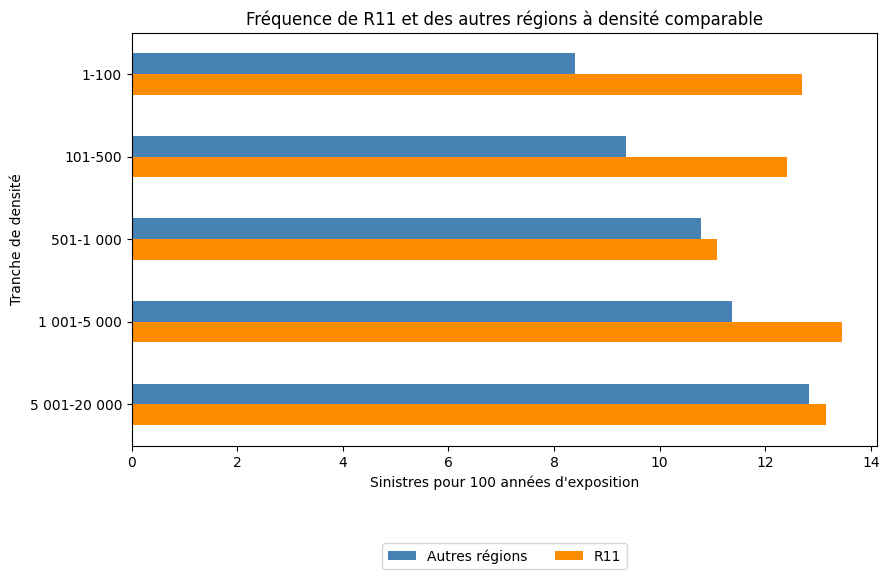

In [12]:
df_region_densite = df_croisements.groupby(
    ['GroupeRegion', 'TrancheDensite'], as_index=False, observed=True
).agg(
    NbContrats=('IDpol', 'count'),
    NbSinistres=('ClaimNb', 'sum'),
    Exposition=('Exposure', 'sum'),
    NbContratsSinistres=('ContratSinistre', 'sum'),
    NbSansMontant=('SansMontant', 'sum')
)
df_region_densite['Frequence100'] = (
    df_region_densite['NbSinistres'] / df_region_densite['Exposition'] * 100
)
df_region_densite['SansMontantPct'] = (
    df_region_densite['NbSansMontant']
    / df_region_densite['NbContratsSinistres'].replace(0, np.nan) * 100
)
print(df_region_densite.round(2).to_string(index=False))

graphique = df_region_densite.pivot(
    index='TrancheDensite', columns='GroupeRegion', values='Frequence100'
)
print("Fréquences comparées, NaN si le groupe n'existe pas :")
print(graphique.round(2))

# Ne pas transformer une absence de groupe de comparaison en fréquence nulle.
# Le graphique garde seulement les tranches présentes des deux côtés.
graphique = graphique.dropna()
graphique.plot.barh(figsize=(9, 6), color=['steelblue', 'darkorange'])
plt.title("Fréquence de R11 et des autres régions à densité comparable")
plt.xlabel("Sinistres pour 100 années d'exposition")
plt.ylabel("Tranche de densité")
plt.gca().invert_yaxis()
plt.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)
plt.tight_layout()
plt.show()

Pour la tranche **1 001-5 000**, R11 est à **13,45**, contre **11,37** pour les autres régions.
Pour la tranche **5 001-20 000**, les fréquences sont plus proches : **13,15** et **12,83**.
L'écart régional n'a donc pas la même ampleur selon la densité.

Les **11 302 contrats de densité supérieure à 20 000** sont tous en R11 dans ce fichier.
Je ne dispose donc pas d'un groupe situé ailleurs pour comparer cette tranche.
Le `NaN` du tableau signifie « aucun groupe de comparaison », et non « zéro sinistre ».

Ces résultats ne prouvent pas un effet propre à R11 : les tranches restent larges et les profils des contrats peuvent différer.

## 6. Vérifier que les croisements conservent le portefeuille

Les filtres des graphiques servent uniquement à la lecture.
Les quatre tableaux de croisement gardent tous les contrats, y compris les âges à vérifier et les durées supérieures à un an.

In [13]:
croisements = {
    'Marque et âge du véhicule': df_marque_vehicule,
    'Âge du véhicule et exposition': df_vehicule_exposition,
    'Âge du conducteur et bonus-malus': df_age_bonus,
    'Région et densité': df_region_densite
}

for nom, tableau in croisements.items():
    contrats_ok = tableau['NbContrats'].sum() == nb_contrats
    sinistres_ok = tableau['NbSinistres'].sum() == nb_sinistres_declares
    exposition_ok = round(tableau['Exposition'].sum(), 6) == round(exposition_totale, 6)
    manquants_ok = tableau['NbSansMontant'].sum() == nb_contrats_sans_montant
    print(nom)
    print("Contrats, sinistres, exposition, contrats sinistrés sans montant :")
    print(contrats_ok, sinistres_ok, exposition_ok, manquants_ok)

Marque et âge du véhicule
Contrats, sinistres, exposition, contrats sinistrés sans montant :
True True True True
Âge du véhicule et exposition
Contrats, sinistres, exposition, contrats sinistrés sans montant :
True True True True
Âge du conducteur et bonus-malus
Contrats, sinistres, exposition, contrats sinistrés sans montant :
True True True True
Région et densité
Contrats, sinistres, exposition, contrats sinistrés sans montant :
True True True True


## 7. B12 / véhicules de 0 an : les durées très courtes expliquent-elles tout ?

Je conserve seulement les véhicules **codés 0 an**, sans supposer leur date exacte de mise en circulation.
Je compare B12 aux autres marques **dans chaque tranche d'exposition**.
Je regarde ensuite ce qui reste au-delà de 0,10 an et de 0,50 an, en appliquant la même règle aux deux groupes.
Ces vues sont des analyses de sensibilité ; les contrats restent dans le portefeuille complet.

  GroupeMarque TrancheExposition  NbContrats  NbSinistres  Exposition  NbContratsSinistres  NbSansMontant  Frequence100  SansMontantPct
Autres marques   Jusqu’à 0,10 an        6226          133      336.89                  131             86         39.48           65.65
Autres marques      0,10-0,50 an        8895          366     2693.56                  350            102         13.59           29.14
Autres marques         0,50-1 an        5377          381     3934.26                  355             74          9.68           20.85
Autres marques      Plus de 1 an         172            7      193.68                    7              0          3.61            0.00
           B12   Jusqu’à 0,10 an       16319         1498      880.88                 1426           1378        170.06           96.63
           B12      0,10-0,50 an       13501         1750     3649.67                 1643           1416         47.95           86.18
           B12         0,50-1 an        7237    

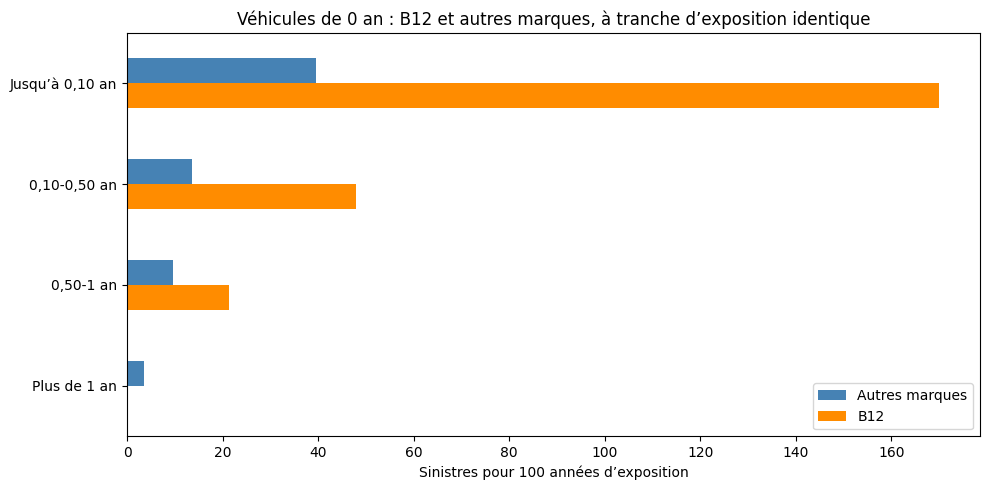

  GroupeMarque  NbContrats  NbSinistres  Exposition  NbContratsSinistres  NbSansMontant  Frequence100  SansMontantPct  ExpositionSuperieureA
Autres marques       20670          887     7158.39                  843            262         12.39           31.08                    0.0
           B12       37069         4318     9560.64                 4079           3553         45.16           87.10                    0.0
Autres marques       14444          754     6821.50                  712            176         11.05           24.72                    0.1
           B12       20750         2820     8679.76                 2653           2175         32.49           81.98                    0.1
Autres marques        5549          388     4127.94                  362             74          9.40           20.44                    0.5
           B12        7249         1070     5030.09                 1010            759         21.27           75.15                    0.5


In [14]:
# Une petite fonction évite de répéter les mêmes calculs dans les trois axes.
def resumer_investigation(donnees, colonnes):
    tableau = donnees.groupby(colonnes, as_index=False, observed=True).agg(
        NbContrats=('IDpol', 'count'),
        NbSinistres=('ClaimNb', 'sum'),
        Exposition=('Exposure', 'sum'),
        NbContratsSinistres=('ContratSinistre', 'sum'),
        NbSansMontant=('SansMontant', 'sum')
    )
    tableau['Frequence100'] = 100 * tableau['NbSinistres'] / tableau['Exposition']
    tableau['SansMontantPct'] = (
        100 * tableau['NbSansMontant']
        / tableau['NbContratsSinistres'].replace(0, np.nan)
    )
    return tableau

df_neufs = df_croisements.loc[df_croisements['VehAge'] == 0].copy()
df_b12_exposition = resumer_investigation(
    df_neufs, ['GroupeMarque', 'TrancheExposition']
)
print(df_b12_exposition.round(2).to_string(index=False))

graphique = df_b12_exposition.pivot(
    index='TrancheExposition', columns='GroupeMarque', values='Frequence100'
)
graphique.plot.barh(figsize=(10, 5), color=['steelblue', 'darkorange'])
plt.title('Véhicules de 0 an : B12 et autres marques, à tranche d’exposition identique')
plt.xlabel('Sinistres pour 100 années d’exposition')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.legend(title='')
plt.tight_layout()
plt.show()

tableaux_sensibilite = []
for seuil in [0, 0.10, 0.50]:
    selection = df_neufs.loc[df_neufs['Exposure'] > seuil]
    tableau = resumer_investigation(selection, ['GroupeMarque'])
    tableau['ExpositionSuperieureA'] = seuil
    tableaux_sensibilite.append(tableau)
df_b12_sensibilite = pd.concat(tableaux_sensibilite, ignore_index=True)
print(df_b12_sensibilite.round(2).to_string(index=False))

assert df_b12_exposition['NbContrats'].sum() == len(df_neufs)
assert df_b12_exposition['NbSinistres'].sum() == df_neufs['ClaimNb'].sum()
assert np.isclose(df_b12_exposition['Exposition'].sum(), df_neufs['Exposure'].sum())

**Ce que je retiens :** l'écart reste présent après exclusion des expositions très courtes.
Entre 0,10 et 0,50 an, la fréquence est **47,95 pour B12 contre 13,59 ailleurs** ;
entre 0,50 et 1 an, **21,33 contre 9,68**. Le groupe B12 de cette dernière tranche
compte **7 237 contrats et 1 070 sinistres**, mais **75,15 %** de ses contrats sinistrés sont sans montant.

En ne regardant que les expositions supérieures à 0,10 an, la fréquence de B12 passe de **45,16 à 32,49**,
contre **11,05** pour les autres marques dans le même périmètre. Le filtre réduit l'écart sans le faire disparaître.
Les durées peuvent encore varier à l'intérieur d'une tranche ; les autres caractéristiques ne sont pas toutes contrôlées.
Au-delà d'un an, B12 ne compte que **12 contrats** : je ne commente pas cette fréquence comme un résultat robuste.

**Suite :** demander la définition du code B12, des véhicules de 0 an et des fenêtres d'exposition,
ainsi que les montants manquants. Leur absence limite les coûts, mais ne change pas directement le calcul de fréquence.

## 8. R24 et R11 : comparer les sous-groupes à ceux des autres régions

Pour chaque région, le groupe « ailleurs » contient **toutes les autres régions**, en excluant la région étudiée.
Je commence par cinq découpages : âge du véhicule, âge du conducteur, bonus-malus, densité et exposition.
Les mêmes contrats apparaissent dans plusieurs découpages : je n'additionne pas leurs effectifs.

Pour les comparaisons mises en avant, je demande **1 000 contrats et 500 années d'exposition de chaque côté**.
Ce sont des seuils de lecture, pas des tests statistiques. Je conserve toutes les lignes dans les exports,
y compris celles sans groupe extérieur ou sous ces seuils.

In [15]:
def comparer_region(donnees, region, colonnes):
    local = resumer_investigation(donnees.loc[donnees['Region'] == region], colonnes)
    ailleurs = resumer_investigation(donnees.loc[donnees['Region'] != region], colonnes)
    # Une jointure externe laisse visibles les profils absents d'un côté.
    comparaison = local.merge(
        ailleurs, on=colonnes, how='outer',
        suffixes=('_region', '_ailleurs'), validate='one_to_one'
    )
    comparaison['RegionEtudiee'] = region
    comparaison['EcartFrequence'] = comparaison['Frequence100_region'] - comparaison['Frequence100_ailleurs']
    comparaison['RatioFrequence'] = (
        comparaison['Frequence100_region']
        / comparaison['Frequence100_ailleurs'].replace(0, np.nan)
    )
    comparaison['ComparaisonLisible'] = (
        (comparaison['NbContrats_region'] >= 1000)
        & (comparaison['Exposition_region'] >= 500)
        & (comparaison['NbContrats_ailleurs'] >= 1000)
        & (comparaison['Exposition_ailleurs'] >= 500)
    )
    # Chaque découpage retrouve le portefeuille, sans additionner plusieurs axes.
    assert comparaison['NbContrats_region'].sum() + comparaison['NbContrats_ailleurs'].sum() == len(donnees)
    assert comparaison['NbSinistres_region'].sum() + comparaison['NbSinistres_ailleurs'].sum() == donnees['ClaimNb'].sum()
    assert np.isclose(
        comparaison['Exposition_region'].sum() + comparaison['Exposition_ailleurs'].sum(),
        donnees['Exposure'].sum()
    )
    return comparaison

axes_region = ['TrancheAgeVehicule', 'TrancheAgeConducteur', 'TrancheBonusMalus',
               'TrancheDensite', 'TrancheExposition']
tableaux_regions = []
for region in ['R24', 'R11']:
    for axe in axes_region:
        tableau = comparer_region(df_croisements, region, [axe])
        tableau = tableau.rename(columns={axe: 'Profil'})
        tableau['Profil'] = tableau['Profil'].astype(str)
        tableau['Axe'] = axe
        tableaux_regions.append(tableau)

df_regions_profils = pd.concat(tableaux_regions, ignore_index=True)
for region in ['R24', 'R11']:
    print('Région étudiée :', region)
    colonnes_lecture = ['Axe', 'Profil', 'NbContrats_region', 'NbSinistres_region',
                       'Exposition_region', 'Frequence100_region', 'Frequence100_ailleurs',
                       'SansMontantPct_region', 'ComparaisonLisible']
    print(df_regions_profils.loc[df_regions_profils['RegionEtudiee'] == region,
                                colonnes_lecture].round(2).to_string(index=False))

Région étudiée : R24
                 Axe                       Profil  NbContrats_region  NbSinistres_region  Exposition_region  Frequence100_region  Frequence100_ailleurs  SansMontantPct_region  ComparaisonLisible
  TrancheAgeVehicule                         0 an             5893.0               315.0            2020.97                15.59                  33.27                  47.97                True
  TrancheAgeVehicule                      1-2 ans            17130.0              1117.0           10709.31                10.43                   8.85                  33.02                True
  TrancheAgeVehicule                      3-5 ans            27678.0              1757.0           18401.02                 9.55                   9.30                  32.94                True
  TrancheAgeVehicule                     6-10 ans            46968.0              2894.0           31283.10                 9.25                  10.26                  27.70                True
  Tr

### 8.1. R24 : des sous-groupes à fréquence élevée derrière une moyenne basse

Les véhicules de **1-2 ans** atteignent **10,43** en R24 contre **8,85** dans les autres régions.
Les conducteurs de **75-99 ans** atteignent **10,66 contre 9,50** ; les **18-24 ans**, malgré une
fréquence de **16,01**, restent sous les **20,42** des autres régions pour ce même âge.
Une fréquence supérieure au portefeuille ne signifie donc pas forcément une particularité de R24.

Je croise ensuite âge du véhicule et bonus-malus. Je montre tous les groupes répondant aux seuils,
pas uniquement ceux dont l'écart va dans le sens recherché.

TrancheAgeVehicule TrancheBonusMalus  NbContrats_region  NbSinistres_region  Exposition_region  Frequence100_region  Frequence100_ailleurs  SansMontantPct_region
           1-2 ans            76-100             1531.0               117.0             689.87                16.96                  12.81                   8.49
           3-5 ans            76-100             3041.0               228.0            1445.25                15.78                  15.29                   7.62
          6-10 ans            76-100             7161.0               490.0            3299.51                14.85                  17.16                   8.01
              0 an       50 ou moins             4305.0               215.0            1533.28                14.02                  30.71                  56.10
         11-20 ans            76-100            11642.0               710.0            5151.76                13.78                  12.82                   5.65
           1-2 ans          

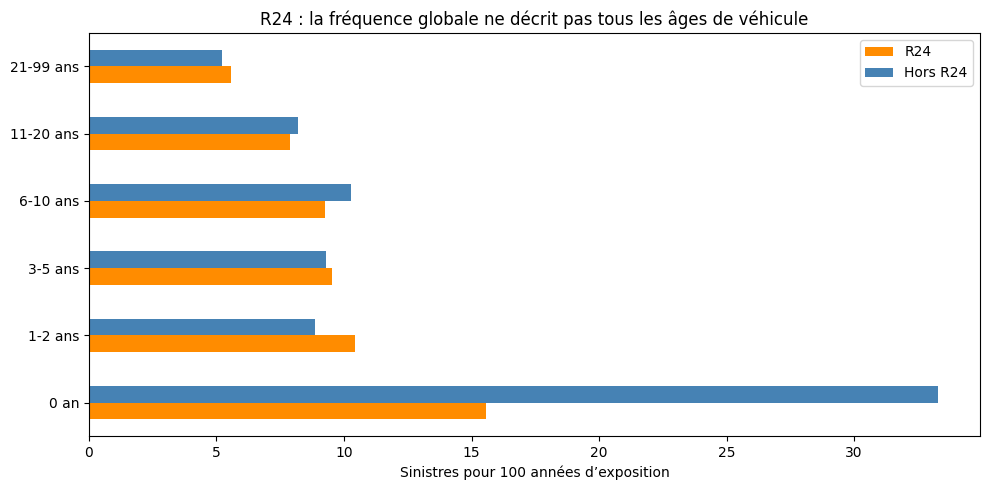

In [16]:
df_r24_croise = comparer_region(
    df_croisements, 'R24', ['TrancheAgeVehicule', 'TrancheBonusMalus']
)
r24_a_lire = df_r24_croise.loc[df_r24_croise['ComparaisonLisible']].copy()
r24_a_lire = r24_a_lire.sort_values('Frequence100_region', ascending=False)
print(r24_a_lire[[
    'TrancheAgeVehicule', 'TrancheBonusMalus', 'NbContrats_region',
    'NbSinistres_region', 'Exposition_region', 'Frequence100_region',
    'Frequence100_ailleurs', 'SansMontantPct_region'
]].round(2).to_string(index=False))

# Le graphique montre le premier découpage ; le tableau détaille le croisement.
graphique = df_regions_profils.loc[
    (df_regions_profils['RegionEtudiee'] == 'R24')
    & (df_regions_profils['Axe'] == 'TrancheAgeVehicule')
    & df_regions_profils['ComparaisonLisible']
].set_index('Profil')[['Frequence100_region', 'Frequence100_ailleurs']]
graphique.columns = ['R24', 'Hors R24']
graphique.plot.barh(figsize=(10, 5), color=['darkorange', 'steelblue'])
plt.title('R24 : la fréquence globale ne décrit pas tous les âges de véhicule')
plt.xlabel('Sinistres pour 100 années d’exposition')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Un groupe à examiner :** en R24, véhicules de **1-2 ans et bonus-malus 76-100** :
**1 531 contrats, 117 sinistres, 689,87 années**, fréquence **16,96 contre 12,81** ailleurs.
La part des contrats sinistrés sans montant est **8,49 %**. C'est un signal descriptif plus précis que la seule région.

Le groupe **1-2 ans / bonus-malus 50 ou moins** est plus volumineux : **11 886 contrats et 747 sinistres**,
fréquence **9,39 contre 7,23** ailleurs. Sa fréquence reste sous celle du portefeuille (10,07),
mais dépasse celle des autres régions pour cette même combinaison. Les montants sont absents pour **44,34 %**
de ses contrats sinistrés : la disponibilité des coûts reste variable.

**Suite :** examiner les circonstances et les autres caractéristiques des sinistres de ces groupes,
avant toute mesure de prévention ou modification de tarif. Les seuils ne prouvent pas la significativité des écarts.

### 8.2. R11 : l'écart change quand on croise densité et bonus-malus

R11 a une fréquence globale de **13,17**. Les véhicules de 0 an y atteignent **40,82 contre 29,07** ailleurs,
mais **82,25 %** de leurs contrats sinistrés n'ont pas de montant retrouvé.
Je complète la comparaison par densité avec le bonus-malus pour préciser l'effet de composition possible.

TrancheDensite TrancheBonusMalus  NbContrats_region  NbSinistres_region  Exposition_region  Frequence100_region  Frequence100_ailleurs  SansMontantPct_region
   1 001-5 000            76-100             4995.0               358.0            1861.36                19.23                  16.90                  38.53
  5 001-20 000            76-100             5237.0               353.0            1835.37                19.23                  18.96                  33.44
       101-500             51-75             1760.0               117.0             783.74                14.93                  10.75                  46.43
   1 001-5 000             51-75             6793.0               412.0            2789.59                14.77                  12.26                  34.99
  5 001-20 000             51-75             6495.0               337.0            2672.25                12.61                  12.70                  29.90
     501-1 000             51-75             1345.0 

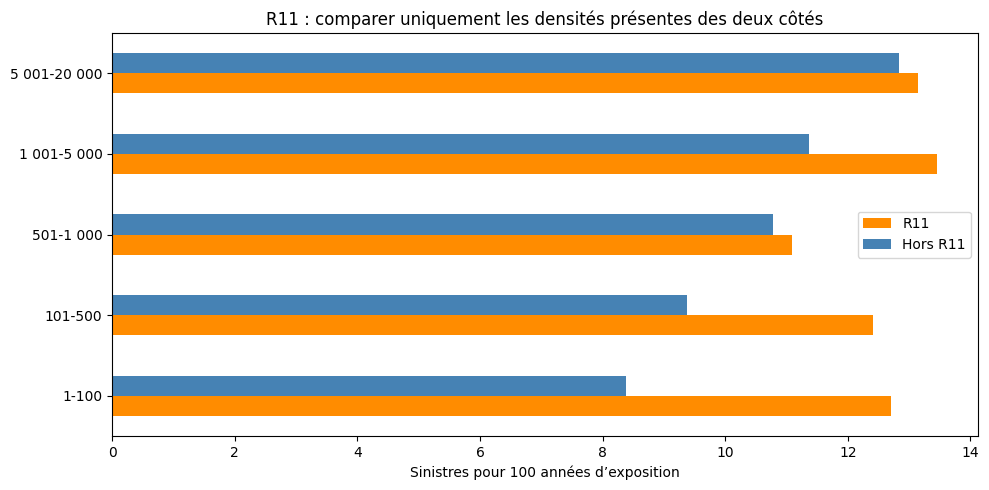

In [17]:
df_r11_croise = comparer_region(
    df_croisements, 'R11', ['TrancheDensite', 'TrancheBonusMalus']
)
r11_a_lire = df_r11_croise.loc[df_r11_croise['ComparaisonLisible']].copy()
r11_a_lire = r11_a_lire.sort_values('Frequence100_region', ascending=False)
print(r11_a_lire[[
    'TrancheDensite', 'TrancheBonusMalus', 'NbContrats_region',
    'NbSinistres_region', 'Exposition_region', 'Frequence100_region',
    'Frequence100_ailleurs', 'SansMontantPct_region'
]].round(2).to_string(index=False))

graphique = df_regions_profils.loc[
    (df_regions_profils['RegionEtudiee'] == 'R11')
    & (df_regions_profils['Axe'] == 'TrancheDensite')
    & df_regions_profils['ComparaisonLisible']
].set_index('Profil')[['Frequence100_region', 'Frequence100_ailleurs']]
graphique.columns = ['R11', 'Hors R11']
graphique.plot.barh(figsize=(10, 5), color=['darkorange', 'steelblue'])
plt.title('R11 : comparer uniquement les densités présentes des deux côtés')
plt.xlabel('Sinistres pour 100 années d’exposition')
plt.ylabel('')
plt.tight_layout()
plt.show()

À densité **5 001-20 000** et bonus-malus **76-100**, les fréquences sont très proches :
**19,23 en R11 contre 18,96 ailleurs**, sur **5 237 contrats en R11**.
Dans cette même densité avec bonus-malus 51-75, **12,61 contre 12,70** : pas de surfréquence observée de R11.

En revanche, à densité **1 001-5 000** et bonus-malus **51-75**, R11 est à **14,77 contre 12,26**,
sur **6 793 contrats, 412 sinistres et 2 789,59 années**. Les montants sont absents pour **34,99 %** des contrats sinistrés.
Le groupe de densité 101-500 / bonus-malus 51-75 reste aussi visible : **14,93 contre 10,75**,
mais seulement **1 760 contrats et 117 sinistres** en R11, avec **46,43 %** de contrats sinistrés sans montant.

La tranche **au-dessus de 20 000** n'existe qu'en R11 : aucune comparaison extérieure n'est possible.
Ces résultats invitent à cibler des profils précis plutôt qu'à supposer un effet identique de R11 sur tous les contrats.

## 9. Sensibilité des résultats régionaux et poids des gros sinistres

Je vérifie séparément les fréquences après mise à l'écart temporaire des très courtes expositions,
des B12 / 0 an, puis des deux ensembles. La même condition est appliquée à la région et à son groupe de comparaison.
Ces scénarios changent le portefeuille étudié : ils n'estiment pas une fréquence « corrigée » ni un effet causal.

Pour les coûts, je repars des montants individuels rapprochés. Retirer une seule occurrence du maximum
sert uniquement à mesurer son influence ; ce sinistre reste dans les données de référence.

In [18]:
scenarios_region = {
    'Portefeuille complet': pd.Series(True, index=df_croisements.index),
    'Exposition > 0,10 an': df_croisements['Exposure'] > 0.10,
    'Sans B12 / 0 an': ~((df_croisements['VehBrand'] == 'B12') & (df_croisements['VehAge'] == 0)),
    'Exposition > 0,10 an et sans B12 / 0 an': (
        (df_croisements['Exposure'] > 0.10)
        & ~((df_croisements['VehBrand'] == 'B12') & (df_croisements['VehAge'] == 0))
    )
}
tableaux_sensibilite = []
for nom, masque in scenarios_region.items():
    selection = df_croisements.loc[masque].copy()
    # Une clé commune permet de réutiliser la comparaison région / ailleurs.
    selection['Scenario'] = nom
    for region in ['R24', 'R11']:
        tableaux_sensibilite.append(comparer_region(selection, region, ['Scenario']))
df_regions_sensibilite = pd.concat(tableaux_sensibilite, ignore_index=True)
print(df_regions_sensibilite[[
    'RegionEtudiee', 'Scenario', 'NbContrats_region', 'NbSinistres_region',
    'Exposition_region', 'Frequence100_region', 'Frequence100_ailleurs', 'SansMontantPct_region'
]].round(2).to_string(index=False))

sinistres_regions = df_sev_rapprochable.merge(
    df_croisements[['IDpol', 'Region']], on='IDpol', how='left', validate='many_to_one'
)
df_couts_regions = sinistres_regions.groupby('Region', as_index=False).agg(
    NbSinistresObserves=('ClaimAmount', 'count'),
    MontantObserve=('ClaimAmount', 'sum'),
    MoyenneObservee=('ClaimAmount', 'mean'),
    MedianeObservee=('ClaimAmount', 'median'),
    PlusGrosMontant=('ClaimAmount', 'max')
)
df_couts_regions['PoidsMaximumPct'] = 100 * df_couts_regions['PlusGrosMontant'] / df_couts_regions['MontantObserve']
df_couts_regions['MoyenneSansUnMaximum'] = (
    (df_couts_regions['MontantObserve'] - df_couts_regions['PlusGrosMontant'])
    / (df_couts_regions['NbSinistresObserves'] - 1).replace(0, np.nan)
)
print(df_couts_regions.loc[df_couts_regions['Region'].isin(['R24', 'R11'])].round(2).to_string(index=False))

assert df_couts_regions['NbSinistresObserves'].sum() == len(df_sev_rapprochable)
assert np.isclose(df_couts_regions['MontantObserve'].sum(), df_sev_rapprochable['ClaimAmount'].sum())

RegionEtudiee                                Scenario  NbContrats_region  NbSinistres_region  Exposition_region  Frequence100_region  Frequence100_ailleurs  SansMontantPct_region
          R24                    Portefeuille complet             160601                9204          102712.90                 8.96                  10.52                  28.91
          R11                    Portefeuille complet              69791                3978           30208.64                13.17                   9.79                  35.55
          R24                    Exposition > 0,10 an             141720                8751          101670.35                 8.61                   9.58                  28.36
          R11                    Exposition > 0,10 an              53828                3375           29328.64                11.51                   9.10                  27.45
          R24                         Sans B12 / 0 an             159727                9153          102

Region  NbSinistresObserves  MontantObserve  MoyenneObservee  MedianeObservee  PlusGrosMontant  PoidsMaximumPct  MoyenneSansUnMaximum
   R11                 2591      4563221.86          1761.18          1172.00        183073.66             4.01               1691.18
   R24                 6475     19074802.36          2945.92          1128.12       4075400.56            21.37               2316.87


Pour R24, le plus gros sinistre représente **21,37 %** des montants observés régionaux.
La moyenne régionale est **2 945,92 €**, contre une médiane de **1 128,12 €**.
Sans une occurrence du maximum, la moyenne serait **2 316,87 €**. Le montant reste conservé.
En R11, le maximum pèse **4,01 %** des coûts observés ; la moyenne passe de **1 761,18 à 1 691,18 €**
dans ce diagnostic. Les deux régions n'ont donc pas la même sensibilité au plus gros sinistre.
Ces résultats portent sur les montants retrouvés, pas sur la charge complète.

Pour la fréquence, le scénario sans B12 / 0 an et avec exposition > 0,10 donne :
- R24 : **8,59 contre 8,76** ailleurs. L'écart régional global devient faible.
- R11 : **9,74 contre 8,62** ailleurs. L'écart se réduit, mais reste visible.

Cela montre la sensibilité des moyennes à la composition du portefeuille. Ces exclusions ne prouvent pas
un effet propre de la région. Elles sont appliquées aux deux côtés et ne changent pas les données de référence.

## 10. Conclusions et actions proposées

| Axe | Résultat nouveau | Action proposée | Ce qui manque |
|---|---|---|---|
| B12 / 0 an | Écart encore présent à exposition 0,50-1 an : 21,33 contre 9,68 | Vérifier codes, périodes et montants, puis comparer les circonstances des sinistres dans cette tranche | Définitions métier et montants manquants ; autres caractéristiques non isolées |
| R24 | Le groupe véhicules 1-2 ans / bonus-malus 76-100 est à 16,96 contre 12,81 | Examiner les 117 sinistres de ce groupe et vérifier les différences de profils | Pas de preuve causale ni de test de significativité |
| R24, coûts | Un seul sinistre représente 21,37 % des montants observés régionaux | Présenter moyenne, médiane et influence du maximum ensemble | Coûts incomplets et circonstances du gros sinistre inconnues |
| R11 | À densité 1 001-5 000 / bonus-malus 51-75 : 14,77 contre 12,26 | Examiner ce groupe en priorité, sans généraliser aux groupes où l'écart se réduit | Profils encore différents sur d'autres variables ; 34,99 % sans montant dans ce groupe |

Je conserve les autres croisements comme éléments de comparaison. Les résultats d'une région sont comparés
à **toutes les autres régions réunies**, et non au portefeuille incluant cette région.
Les seuils de 1 000 contrats et 500 années sont exploratoires. Ils ne rendent pas automatiquement un écart significatif.
Les groupes peuvent se recouper : on ne cumule pas leurs volumes entre axes.

Le rapport Power BI comporte désormais cinq pages : vue d'ensemble, B12 / 0 an, R24, R11, qualité.
Les coûts inconnus restent inconnus ; aucune analyse ne mesure une rentabilité ou ne justifie à elle seule un changement de tarif.

## 11. Exporter les données pour Power BI

Je garde deux grains : **une ligne par contrat** dans `contrats.csv` et **une ligne par sinistre observé** dans `sinistres.csv`.
La relation utilisera `IDpol`, du contrat vers ses sinistres. Les fréquences seront calculées depuis les contrats et les coûts depuis les sinistres.

Les orphelins restent dans un fichier séparé, car leurs caractéristiques sont inconnues. `LigneSource` indique la position de la ligne dans `sev` : ce n'est pas un identifiant de sinistre fourni par la source.

Les fichiers sont enregistrés dans `data/processed`, en UTF-8, avec `;` comme séparateur et un point décimal. Les valeurs manquantes restent vides. `controle_kpi.csv` sert de référence pour vérifier Power BI ; je ne l'utilise pas pour calculer les mesures du rapport.

Six tableaux d'investigation supplémentaires sont exportés pour contrôler et relire les résultats.
Ils ne sont pas importés dans Power BI : les visuels recalculent leurs ratios à partir des tables détaillées.
Une ligne de comparaison représente une région, un axe et un profil, ou une combinaison de deux profils.
Les tableaux de sensibilité sont des scénarios distincts à ne pas additionner.

In [19]:
from pathlib import Path

dossier_export = racine / 'data/processed'
dossier_export.mkdir(parents=True, exist_ok=True)

# Garder les caractéristiques et les sinistres déclarés au grain contrat.
# Les montants seront calculés depuis la table des sinistres individuels.
contrats_export = df_croisements.drop(columns=['NbSinister', 'TotalAmount']).copy()

# Conserver l'ordre des tranches dans Power BI.
for colonne in segments_tranches + ['TrancheExposition']:
    contrats_export['Ordre_' + colonne] = contrats_export[colonne].cat.codes + 1

sinistres_export = df_sev_rapprochable.copy()
sinistres_export.insert(0, 'LigneSource', sinistres_export.index + 1)

orphelins_export = df_sev_orphelins.copy()
orphelins_export.insert(0, 'LigneSource', orphelins_export.index + 1)

tables_export = {
    'contrats': contrats_export,
    'sinistres': sinistres_export,
    'orphelins': orphelins_export,
    'controle_kpi': df_kpi,
    'investigation_b12_exposition': df_b12_exposition,
    'investigation_b12_sensibilite': df_b12_sensibilite,
    'investigation_regions_profils': df_regions_profils,
    'investigation_regions_croisees': pd.concat([
        df_r24_croise.assign(Axe='AgeVehicule x BonusMalus'),
        df_r11_croise.assign(Axe='Densite x BonusMalus')
    ], ignore_index=True),
    'investigation_regions_sensibilite': df_regions_sensibilite,
    'investigation_couts_regions': df_couts_regions
}

for nom, table in tables_export.items():
    table.to_csv(dossier_export / f'{nom}.csv', index=False, sep=';', encoding='utf-8-sig')
    print(nom, ':', len(table), 'lignes exportées')

# Relire les fichiers pour vérifier les clés et les totaux après export.
contrats_relus = pd.read_csv(dossier_export / 'contrats.csv', sep=';')
sinistres_relus = pd.read_csv(dossier_export / 'sinistres.csv', sep=';')
orphelins_relus = pd.read_csv(dossier_export / 'orphelins.csv', sep=';')

assert len(contrats_relus) == nb_contrats
assert contrats_relus['IDpol'].is_unique
assert contrats_relus['ClaimNb'].sum() == nb_sinistres_declares
assert np.isclose(contrats_relus['Exposure'].sum(), exposition_totale)
assert sinistres_relus['IDpol'].isin(contrats_relus['IDpol']).all()
assert not orphelins_relus['IDpol'].isin(contrats_relus['IDpol']).any()
assert len(sinistres_relus) == nb_sinistres_observes
assert round(sinistres_relus['ClaimAmount'].sum(), 2) == round(montant_observe, 2)
assert len(sinistres_relus) + len(orphelins_relus) == len(df_sev)
assert round(sinistres_relus['ClaimAmount'].sum() + orphelins_relus['ClaimAmount'].sum(), 2) == round(df_sev['ClaimAmount'].sum(), 2)

print('Contrôles des exports : OK')

contrats : 678013 lignes exportées
sinistres : 26444 lignes exportées
orphelins : 195 lignes exportées
controle_kpi : 1 lignes exportées
investigation_b12_exposition : 8 lignes exportées
investigation_b12_sensibilite : 6 lignes exportées
investigation_regions_profils : 64 lignes exportées
investigation_regions_croisees : 81 lignes exportées
investigation_regions_sensibilite : 8 lignes exportées
investigation_couts_regions : 22 lignes exportées


Contrôles des exports : OK
